# NB11 — Compact 1D-CNN Reviewer Benchmark | NIR-HUEVOS 2026

**Purpose.** Add one architecture whose inductive bias matches local wavelength structure, while preserving the previously frozen primary analysis. This is an explicitly labelled **additional reviewer analysis**; it does not retroactively replace NB01–NB10.

Scientific safeguards:

- the egg (`sample`) is the independent biological unit;
- exact NB02 outer and inner egg-disjoint assignments are reused;
- preprocessing is fitted on training eggs only;
- the outer test eggs never influence preprocessing, epoch choice, or model selection;
- architecture and training settings are fixed in this notebook before results are examined;
- final outer refits use seeds 2026, 2027, and 2028;
- checkpoints are written to Google Drive after every fit.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Imports, paths, fixed protocol, and GPU gate
from pathlib import Path
from datetime import datetime, timezone
import gc, hashlib, json, os, platform, random, shutil, subprocess, sys, time, warnings

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings('ignore')
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

PROJECT_ROOT = Path('/content/drive/MyDrive/NIR_HUEVOS_PAPER_REBUILD_2026')
RAW_DIR = PROJECT_ROOT / '01_DATA_RAW'
SPLIT_DIR = PROJECT_ROOT / '03_SPLITS_FROZEN'
NOTEBOOK_DIR = PROJECT_ROOT / '04_NOTEBOOKS' / 'REVISION_REVIEWERS_2026_09'
ROUND_RESULT_DIR = PROJECT_ROOT / '05_RESULTS' / 'REVISION_REVIEWERS_2026_09'
RESULT_DIR = ROUND_RESULT_DIR / 'NB11_CNN1D_REVIEWER_BENCHMARK'
FIG_DIR = PROJECT_ROOT / '06_FIGURES' / 'REVISION_REVIEWERS_2026_09' / 'NB11_CNN1D_REVIEWER_BENCHMARK'
CHECKPOINT_DIR = RESULT_DIR / '_CHECKPOINT'
for p in [NOTEBOOK_DIR, RESULT_DIR, FIG_DIR, CHECKPOINT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DATA_FILE = RAW_DIR / 'dataset_egg_storage_RAW.csv'
OUTER_FILE = SPLIT_DIR / 'outer_group_assignment_seed2026.csv'
SPLIT_MANIFEST_FILE = SPLIT_DIR / 'split_manifest.json'
EXPECTED_DATASET_SHA256 = 'cd5021c555ae6b57f892549c574599cef75edf87f58b3f7f4d246ade9327d15e'

MODEL_NAME = 'CNN1D'
PREPROCESSING_CANDIDATES = ['raw', 'snv', 'msc', 'sg_smooth', 'sg_deriv1']
FINAL_SEEDS = [2026, 2027, 2028]
SG_WINDOW, SG_POLYORDER = 11, 2
MAX_EPOCHS = 250
PATIENCE = 20
MIN_DELTA = 1e-3
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
RUN_REVISION = 'NB11_v1_compact_cnn1d_fixed_architecture_frozen_splits'
RESUME_IF_AVAILABLE = True

gpus = tf.config.list_physical_devices('GPU')
print('TensorFlow:', tf.__version__, '| GPU:', gpus)
assert gpus, 'Select Runtime > Change runtime type > GPU in Google Colab.'
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass
try:
    hardware = subprocess.check_output(['nvidia-smi'], text=True, stderr=subprocess.STDOUT)
except Exception as exc:
    hardware = f'nvidia-smi unavailable: {exc}'
(RESULT_DIR / 'NB11_hardware_info.txt').write_text(hardware, encoding='utf-8')
print('Paths and fixed protocol initialized.')


TensorFlow: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Paths and fixed protocol initialized.


In [3]:
# Integrity gate: raw dataset and frozen NB02 split files
def sha256_file(path, chunk_size=1024*1024):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            h.update(chunk)
    return h.hexdigest()

assert DATA_FILE.exists(), f'Missing dataset: {DATA_FILE}'
assert OUTER_FILE.exists(), f'Missing outer assignment: {OUTER_FILE}'
assert SPLIT_MANIFEST_FILE.exists(), f'Missing split manifest: {SPLIT_MANIFEST_FILE}'
dataset_sha = sha256_file(DATA_FILE)
assert dataset_sha == EXPECTED_DATASET_SHA256, f'Unexpected dataset hash: {dataset_sha}'
manifest = json.loads(SPLIT_MANIFEST_FILE.read_text(encoding='utf-8'))
split_manifest_sha = sha256_file(SPLIT_MANIFEST_FILE)
hash_rows = []
for name, expected in manifest['files'].items():
    path = SPLIT_DIR / name
    observed = sha256_file(path)
    hash_rows.append({'file': name, 'expected_sha256': expected, 'observed_sha256': observed, 'match': observed == expected})
hash_audit = pd.DataFrame(hash_rows)
assert hash_audit['match'].all(), 'A frozen NB02 split file has changed.'
hash_audit.to_csv(RESULT_DIR / 'NB11_input_hash_audit.csv', index=False)

STATE_FILE = CHECKPOINT_DIR / 'checkpoint_state.json'
if STATE_FILE.exists() and RESUME_IF_AVAILABLE:
    state = json.loads(STATE_FILE.read_text(encoding='utf-8'))
    assert state['run_revision'] == RUN_REVISION, 'Checkpoint belongs to another NB11 protocol revision.'
    assert state['dataset_sha256'] == dataset_sha and state['split_manifest_sha256'] == split_manifest_sha
    print('Valid checkpoint found; completed units will be skipped.')
else:
    state = {
        'run_revision': RUN_REVISION,
        'dataset_sha256': dataset_sha,
        'split_manifest_sha256': split_manifest_sha,
        'started_at_utc': datetime.now(timezone.utc).isoformat(),
        'status': 'IN_PROGRESS'
    }
    STATE_FILE.write_text(json.dumps(state, indent=2), encoding='utf-8')
print('PASS — data and frozen splits are unchanged.')


PASS — data and frozen splits are unchanged.


In [4]:
# Load data and revalidate egg-disjoint outer/inner topology
df = pd.read_csv(DATA_FILE)
outer = pd.read_csv(OUTER_FILE)
spectral_cols = sorted(
    [c for c in df.columns if c.startswith('Spectra_')],
    key=lambda c: float(c.replace('Spectra_', ''))
)
assert spectral_cols[0] == 'Spectra_740' and spectral_cols[-1] == 'Spectra_1070'
X_all = df[spectral_cols].to_numpy(dtype=np.float32)
y_all = df['storage_days'].to_numpy(dtype=np.float32)
assert X_all.shape == (660, 331)
assert df['sample'].nunique() == 30 and df['storage_days'].nunique() == 22

def get_outer_eggs(fold):
    test = set(outer.loc[outer['outer_fold'] == fold, 'sample'].astype(int))
    train = set(df['sample'].astype(int).unique()) - test
    assert len(train) == 24 and len(test) == 6 and not (train & test)
    return train, test

def get_inner(fold):
    inner = pd.read_csv(SPLIT_DIR / f'inner_group_assignment_outer{fold:02d}.csv')
    train, test = get_outer_eggs(fold)
    assert set(inner['sample'].astype(int)) == train
    assert not (set(inner['sample'].astype(int)) & test)
    return inner

audit = []
for fold in range(1, 6):
    outer_train, outer_test = get_outer_eggs(fold)
    inner = get_inner(fold)
    for inner_fold in range(1, 5):
        val = set(inner.loc[inner['inner_fold'] == inner_fold, 'sample'].astype(int))
        train = outer_train - val
        audit.append({
            'outer_fold': fold, 'inner_fold': inner_fold,
            'outer_train_eggs': len(outer_train), 'outer_test_eggs': len(outer_test),
            'inner_train_eggs': len(train), 'inner_val_eggs': len(val),
            'outer_overlap': len(outer_train & outer_test),
            'inner_overlap': len(train & val),
            'outer_test_in_inner': len(outer_test & (train | val))
        })
audit = pd.DataFrame(audit)
assert (audit[['outer_overlap', 'inner_overlap', 'outer_test_in_inner']] == 0).all().all()
audit.to_csv(RESULT_DIR / 'NB11_split_revalidation.csv', index=False)
display(audit.head())


,outer_fold,inner_fold,outer_train_eggs,outer_test_eggs,inner_train_eggs,inner_val_eggs,outer_overlap,inner_overlap,outer_test_in_inner
0,1,1,24,6,18,6,0,0,0
1,1,2,24,6,18,6,0,0,0
2,1,3,24,6,18,6,0,0,0
3,1,4,24,6,18,6,0,0,0
4,2,1,24,6,18,6,0,0,0


## Leakage-safe preprocessing and fixed compact CNN

The CNN architecture is fixed before evaluation. Only the same five preprocessing candidates used in the earlier benchmark are selected inside the frozen inner folds. The convolutional kernels act locally along the wavelength axis; recurrence is not used.


In [5]:
class SpectralPreprocessor:
    def __init__(self, name):
        self.name = name
        self.reference_ = None
        self.scaler_ = None

    def _base(self, X):
        X = np.asarray(X, dtype=np.float64)
        if self.name == 'raw':
            return X.copy()
        if self.name == 'snv':
            mu = X.mean(axis=1, keepdims=True)
            sd = X.std(axis=1, ddof=1, keepdims=True)
            return (X - mu) / np.where(sd < 1e-12, 1.0, sd)
        if self.name == 'msc':
            if self.reference_ is None:
                raise RuntimeError('MSC reference is not fitted.')
            ref = self.reference_
            rc = ref - ref.mean()
            denom = np.dot(rc, rc)
            out = np.empty_like(X)
            for i, x in enumerate(X):
                b = np.dot(rc, x - x.mean()) / denom
                b = 1.0 if abs(b) < 1e-12 else b
                a = x.mean() - b * ref.mean()
                out[i] = (x - a) / b
            return out
        deriv = 0 if self.name == 'sg_smooth' else 1
        if self.name in ['sg_smooth', 'sg_deriv1']:
            return savgol_filter(X, 11, 2, deriv=deriv, delta=1.0, axis=1, mode='interp')
        raise ValueError(self.name)

    def fit(self, X):
        X = np.asarray(X, dtype=np.float64)
        if self.name == 'msc':
            self.reference_ = X.mean(axis=0)
        self.scaler_ = StandardScaler().fit(self._base(X))
        return self

    def transform(self, X):
        return self.scaler_.transform(self._base(X)).astype(np.float32)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

def set_seeds(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

def build_cnn1d(n_features=331):
    inp = keras.Input(shape=(n_features, 1), name='ordered_spectrum')
    x = layers.Conv1D(16, 7, padding='same', activation='relu', name='conv_local_7nm')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(32, 5, padding='same', activation='relu', name='conv_local_5nm')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.20)(x)
    out = layers.Dense(1, activation='linear')(x)
    model = keras.Model(inp, out, name='CompactCNN1D')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='mse', metrics=[keras.metrics.MeanAbsoluteError(name='mae')]
    )
    return model

def metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    ae = np.abs(y_pred - y_true)
    return {
        'MAE_days': float(mean_absolute_error(y_true, y_pred)),
        'RMSE_days': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'R2': float(r2_score(y_true, y_pred)),
        'bias_days': float(np.mean(y_pred - y_true)),
        'median_AE_days': float(np.median(ae)),
        'within_1d_pct': float(100*np.mean(ae <= 1)),
        'within_2d_pct': float(100*np.mean(ae <= 2)),
        'within_3d_pct': float(100*np.mean(ae <= 3)),
    }

tf.keras.backend.clear_session()
set_seeds(2026)
model = build_cnn1d()
complexity = pd.DataFrame([{
    'model': MODEL_NAME, 'parameter_count': int(model.count_params()),
    'estimated_fp32_weight_bytes': int(model.count_params()*4),
    'input_shape': str(model.input_shape), 'output_shape': str(model.output_shape)
}])
complexity.to_csv(RESULT_DIR / 'NB11_model_complexity.csv', index=False)
display(complexity)
del model
gc.collect()


,model,parameter_count,estimated_fp32_weight_bytes,input_shape,output_shape
0,CNN1D,4001,16004,"(None, 331, 1)","(None, 1)"


1434

In [6]:
# Resumable inner selection: 5 outer folds × 5 preprocessors × 4 inner folds
CP_INNER = CHECKPOINT_DIR / 'inner_foldwise.csv'
CP_SELECTED = CHECKPOINT_DIR / 'selected_configurations.csv'

def load_csv(path):
    return pd.read_csv(path) if path.exists() and path.stat().st_size else pd.DataFrame()

def atomic_csv(frame, path):
    tmp = path.with_suffix(path.suffix + '.tmp')
    frame.to_csv(tmp, index=False)
    os.replace(tmp, path)

inner_rows = load_csv(CP_INNER)
selected = load_csv(CP_SELECTED)

for outer_fold in range(1, 6):
    outer_train_eggs, outer_test_eggs = get_outer_eggs(outer_fold)
    inner = get_inner(outer_fold)
    print(f'OUTER {outer_fold}/5')
    for prep_idx, prep_name in enumerate(PREPROCESSING_CANDIDATES):
        for inner_fold in range(1, 5):
            done = (not inner_rows.empty and (
                (inner_rows.outer_fold == outer_fold) &
                (inner_rows.preprocessing == prep_name) &
                (inner_rows.inner_fold == inner_fold)
            ).any())
            if done:
                continue
            val_eggs = set(inner.loc[inner.inner_fold == inner_fold, 'sample'].astype(int))
            train_eggs = outer_train_eggs - val_eggs
            tr = df['sample'].astype(int).isin(train_eggs).to_numpy()
            va = df['sample'].astype(int).isin(val_eggs).to_numpy()
            assert not (train_eggs & val_eggs) and not (outer_test_eggs & (train_eggs | val_eggs))

            pp = SpectralPreprocessor(prep_name)
            Xtr = pp.fit_transform(X_all[tr])[..., None]
            Xva = pp.transform(X_all[va])[..., None]
            seed = 61000 + outer_fold*100 + prep_idx*10 + inner_fold
            tf.keras.backend.clear_session(); set_seeds(seed)
            model = build_cnn1d()
            callbacks = [keras.callbacks.EarlyStopping(
                monitor='val_mae', mode='min', patience=PATIENCE,
                min_delta=MIN_DELTA, restore_best_weights=True
            )]
            start = time.perf_counter()
            hist = model.fit(
                Xtr, y_all[tr], validation_data=(Xva, y_all[va]),
                epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, verbose=0,
                shuffle=True, callbacks=callbacks
            )
            elapsed = time.perf_counter() - start
            best_epoch = int(np.argmin(hist.history['val_mae']) + 1)
            pred = model.predict(Xva, verbose=0).reshape(-1)
            row = {
                'outer_fold': outer_fold, 'inner_fold': inner_fold,
                'preprocessing': prep_name, 'seed': seed,
                'best_epoch': best_epoch, 'epochs_ran': len(hist.history['loss']),
                'fit_seconds': elapsed, 'train_eggs': len(train_eggs),
                'val_eggs': len(val_eggs), **metrics(y_all[va], pred)
            }
            inner_rows = pd.concat([inner_rows, pd.DataFrame([row])], ignore_index=True)
            atomic_csv(inner_rows, CP_INNER)
            print(f"  {prep_name:9s} inner {inner_fold}/4 | MAE={row['MAE_days']:.3f} | epoch={best_epoch}")
            del pp, Xtr, Xva, model, hist, pred
            tf.keras.backend.clear_session(); gc.collect()

    if selected.empty or not (selected.outer_fold == outer_fold).any():
        sub = inner_rows[inner_rows.outer_fold == outer_fold]
        summary = sub.groupby('preprocessing', as_index=False).agg(
            mean_inner_MAE_days=('MAE_days', 'mean'),
            sd_inner_MAE_days=('MAE_days', 'std'),
            median_best_epoch=('best_epoch', 'median')
        ).sort_values(['mean_inner_MAE_days', 'preprocessing'])
        best = summary.iloc[0]
        chosen = {
            'outer_fold': outer_fold,
            'preprocessing': best.preprocessing,
            'selected_epoch': int(max(1, round(best.median_best_epoch))),
            'mean_inner_MAE_days': float(best.mean_inner_MAE_days),
            'sd_inner_MAE_days': float(best.sd_inner_MAE_days),
            'selection_rule': 'minimum mean MAE across four frozen inner egg-disjoint folds'
        }
        selected = pd.concat([selected, pd.DataFrame([chosen])], ignore_index=True)
        atomic_csv(selected, CP_SELECTED)
        print('SELECTED:', chosen)

assert len(inner_rows) == 100 and len(selected) == 5
inner_rows.sort_values(['outer_fold','preprocessing','inner_fold']).to_csv(RESULT_DIR / 'NB11_inner_foldwise.csv', index=False)
selected.sort_values('outer_fold').to_csv(RESULT_DIR / 'NB11_selected_configurations.csv', index=False)
display(selected.sort_values('outer_fold'))


OUTER 1/5
  raw       inner 1/4 | MAE=4.833 | epoch=55
  raw       inner 2/4 | MAE=4.575 | epoch=92


  raw       inner 3/4 | MAE=4.760 | epoch=82
  raw       inner 4/4 | MAE=4.213 | epoch=57
  snv       inner 1/4 | MAE=4.570 | epoch=141
  snv       inner 2/4 | MAE=5.160 | epoch=30
  snv       inner 3/4 | MAE=5.657 | epoch=15
  snv       inner 4/4 | MAE=4.371 | epoch=50
  msc       inner 1/4 | MAE=4.755 | epoch=99
  msc       inner 2/4 | MAE=5.033 | epoch=22
  msc       inner 3/4 | MAE=5.024 | epoch=24
  msc       inner 4/4 | MAE=4.329 | epoch=78
  sg_smooth inner 1/4 | MAE=4.874 | epoch=70
  sg_smooth inner 2/4 | MAE=4.703 | epoch=124
  sg_smooth inner 3/4 | MAE=4.480 | epoch=126
  sg_smooth inner 4/4 | MAE=4.325 | epoch=67
  sg_deriv1 inner 1/4 | MAE=4.060 | epoch=87
  sg_deriv1 inner 2/4 | MAE=4.564 | epoch=45
  sg_deriv1 inner 3/4 | MAE=4.795 | epoch=40
  sg_deriv1 inner 4/4 | MAE=3.906 | epoch=85
SELECTED: {'outer_fold': 1, 'preprocessing': 'sg_deriv1', 'selected_epoch': 65, 'mean_inner_MAE_days': 4.3313716839660295, 'sd_inner_MAE_days': 0.41783863068801824, 'selection_rule': 'min

,outer_fold,preprocessing,selected_epoch,mean_inner_MAE_days,sd_inner_MAE_days,selection_rule
0,1,sg_deriv1,65,4.331372,0.417839,minimum mean MAE across four frozen inner egg-...
1,2,sg_deriv1,39,4.413775,0.649974,minimum mean MAE across four frozen inner egg-...
2,3,sg_deriv1,86,4.312082,0.694034,minimum mean MAE across four frozen inner egg-...
3,4,sg_deriv1,82,4.380206,0.475619,minimum mean MAE across four frozen inner egg-...
4,5,sg_deriv1,68,4.246693,0.519775,minimum mean MAE across four frozen inner egg-...


In [7]:
# Final outer refits: 5 folds × 3 seeds; outer test eggs remain untouched until prediction
CP_METRICS = CHECKPOINT_DIR / 'outer_fold_seed_metrics.csv'
CP_PRED = CHECKPOINT_DIR / 'oof_predictions_seedwise.csv'
outer_metrics = load_csv(CP_METRICS)
oof = load_csv(CP_PRED)

for outer_fold in range(1, 6):
    train_eggs, test_eggs = get_outer_eggs(outer_fold)
    tr = df['sample'].astype(int).isin(train_eggs).to_numpy()
    te = df['sample'].astype(int).isin(test_eggs).to_numpy()
    cfg = selected.loc[selected.outer_fold == outer_fold].iloc[0]
    pp = SpectralPreprocessor(cfg.preprocessing)
    Xtr = pp.fit_transform(X_all[tr])[..., None]
    Xte = pp.transform(X_all[te])[..., None]
    test_meta = df.loc[te, ['sample', 'storage_days']].reset_index(drop=True)
    for seed in FINAL_SEEDS:
        done = (not outer_metrics.empty and (
            (outer_metrics.outer_fold == outer_fold) & (outer_metrics.seed == seed)
        ).any())
        if done:
            continue
        tf.keras.backend.clear_session(); set_seeds(seed)
        model = build_cnn1d()
        start = time.perf_counter()
        model.fit(
            Xtr, y_all[tr], epochs=int(cfg.selected_epoch),
            batch_size=BATCH_SIZE, verbose=0, shuffle=True
        )
        fit_seconds = time.perf_counter() - start
        start = time.perf_counter()
        pred = model.predict(Xte, verbose=0).reshape(-1)
        inference_seconds = time.perf_counter() - start
        mm = {
            'outer_fold': outer_fold, 'model': MODEL_NAME, 'seed': seed,
            'preprocessing': cfg.preprocessing, 'selected_epoch': int(cfg.selected_epoch),
            'train_eggs': len(train_eggs), 'test_eggs': len(test_eggs),
            'fit_seconds': fit_seconds,
            'inference_ms_per_spectrum': 1000*inference_seconds/len(pred),
            **metrics(y_all[te], pred)
        }
        outer_metrics = pd.concat([outer_metrics, pd.DataFrame([mm])], ignore_index=True)
        pred_rows = pd.DataFrame({
            'sample': test_meta['sample'].astype(int),
            'storage_days': test_meta['storage_days'].astype(int),
            'outer_fold': outer_fold, 'model': MODEL_NAME, 'seed': seed,
            'y_pred': pred.astype(float)
        })
        oof = pd.concat([oof, pred_rows], ignore_index=True)
        atomic_csv(outer_metrics, CP_METRICS); atomic_csv(oof, CP_PRED)
        print(f"outer={outer_fold}, seed={seed}, MAE={mm['MAE_days']:.3f}")
        del model, pred, pred_rows
        tf.keras.backend.clear_session(); gc.collect()
    del pp, Xtr, Xte

assert len(outer_metrics) == 15
assert len(oof) == 660*3
assert not oof.duplicated(['sample','storage_days','seed']).any()
for seed in FINAL_SEEDS:
    assert set(zip(oof.loc[oof.seed == seed, 'sample'], oof.loc[oof.seed == seed, 'storage_days'])) == set(zip(df['sample'], df['storage_days']))

oof_mean = oof.groupby(['sample','storage_days','outer_fold','model'], as_index=False).agg(
    y_pred=('y_pred','mean'), seed_sd=('y_pred','std')
)
outer_metrics.sort_values(['outer_fold','seed']).to_csv(RESULT_DIR / 'NB11_outer_fold_seed_metrics.csv', index=False)
oof.sort_values(['seed','sample','storage_days']).to_csv(RESULT_DIR / 'NB11_oof_predictions_seedwise.csv', index=False)
oof_mean.sort_values(['sample','storage_days']).to_csv(RESULT_DIR / 'NB11_oof_predictions_seedmean.csv', index=False)
print('PASS — all 15 outer CNN1D refits and 1,980 seed-wise OOF predictions are complete.')


outer=1, seed=2026, MAE=4.380
outer=1, seed=2027, MAE=4.366
outer=1, seed=2028, MAE=4.428
outer=2, seed=2026, MAE=5.620
outer=2, seed=2027, MAE=5.482
outer=2, seed=2028, MAE=5.373
outer=3, seed=2026, MAE=5.520
outer=3, seed=2027, MAE=4.827
outer=3, seed=2028, MAE=4.261
outer=4, seed=2026, MAE=4.187
outer=4, seed=2027, MAE=4.393
outer=4, seed=2028, MAE=4.227
outer=5, seed=2026, MAE=4.193
outer=5, seed=2027, MAE=4.072
outer=5, seed=2028, MAE=4.097
PASS — all 15 outer CNN1D refits and 1,980 seed-wise OOF predictions are complete.


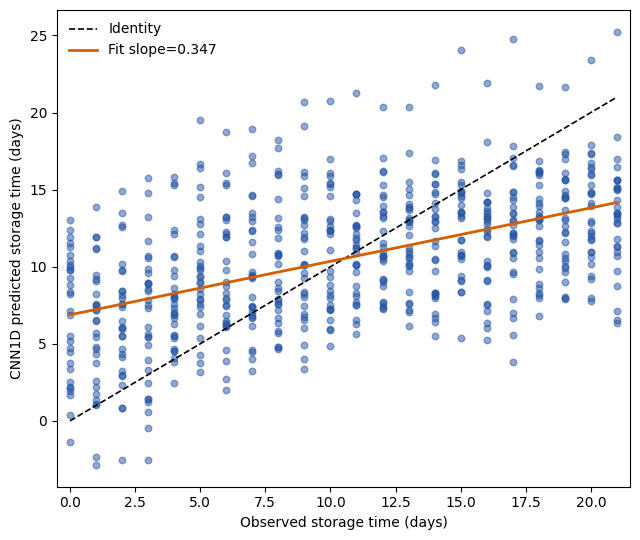

,model,MAE_days,RMSE_days,R2,bias_days,median_AE_days,within_1d_pct,within_2d_pct,within_3d_pct
0,CNN1D,4.571915,5.623247,0.214387,0.022471,4.00183,12.727273,25.151515,40.151515


In [8]:
# Descriptive summaries and diagnostic figure
pooled_seedwise = pd.DataFrame([
    {'model': MODEL_NAME, 'seed': int(seed), **metrics(g.storage_days, g.y_pred)}
    for seed, g in oof.groupby('seed')
])
pooled = pd.DataFrame([{'model': MODEL_NAME, **metrics(oof_mean.storage_days, oof_mean.y_pred)}])
per_egg = pd.DataFrame([
    {'model': MODEL_NAME, 'sample': int(sample), **metrics(g.storage_days, g.y_pred)}
    for sample, g in oof_mean.groupby('sample')
])
by_day = pd.DataFrame([
    {'model': MODEL_NAME, 'storage_days': int(day), 'n': len(g), **metrics(g.storage_days, g.y_pred)}
    for day, g in oof_mean.groupby('storage_days')
])
pooled_seedwise.to_csv(RESULT_DIR / 'NB11_pooled_seedwise_metrics.csv', index=False)
pooled.to_csv(RESULT_DIR / 'NB11_pooled_seedmean_metrics.csv', index=False)
per_egg.to_csv(RESULT_DIR / 'NB11_per_egg_metrics.csv', index=False)
by_day.to_csv(RESULT_DIR / 'NB11_metrics_by_storage_day.csv', index=False)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(oof_mean.storage_days, oof_mean.y_pred, s=22, alpha=.5, color='#2455A4')
ax.plot([0,21], [0,21], '--', color='black', lw=1.2, label='Identity')
coef = np.polyfit(oof_mean.storage_days, oof_mean.y_pred, 1)
ax.plot([0,21], np.polyval(coef, [0,21]), color='#D55E00', lw=2, label=f'Fit slope={coef[0]:.3f}')
ax.set(xlabel='Observed storage time (days)', ylabel='CNN1D predicted storage time (days)', xlim=(-.5,21.5))
ax.legend(frameon=False); fig.tight_layout()
fig.savefig(FIG_DIR / 'NB11_CNN1D_observed_vs_predicted.png', dpi=600, bbox_inches='tight')
fig.savefig(FIG_DIR / 'NB11_CNN1D_observed_vs_predicted.svg', bbox_inches='tight')
plt.show()
display(pooled)


In [9]:
# Freeze protocol and completion status
protocol = {
    'notebook': 'NB11_CNN1D_REVIEWER_BENCHMARK.ipynb',
    'analysis_role': 'additional reviewer analysis; frozen primary NB01-NB10 unchanged',
    'run_revision': RUN_REVISION,
    'dataset_sha256': dataset_sha,
    'split_manifest_sha256': split_manifest_sha,
    'grouping_unit': 'sample (egg)', 'n_independent_eggs': 30,
    'n_spectra': 660, 'n_wavelengths': 331,
    'outer_folds': 5, 'inner_folds': 4,
    'preprocessing_candidates': PREPROCESSING_CANDIDATES,
    'architecture': 'Conv1D(16,k=7)-BN-MaxPool-Conv1D(32,k=5)-BN-GAP-Dense(32)-Dropout(0.20)-Linear',
    'optimizer': 'Adam', 'learning_rate': LEARNING_RATE,
    'batch_size': BATCH_SIZE, 'max_inner_epochs': MAX_EPOCHS,
    'early_stopping': {'monitor':'val_mae','patience':PATIENCE,'min_delta':MIN_DELTA,'restore_best_weights':True},
    'epoch_rule': 'median best inner-fold epoch for selected preprocessing',
    'final_seeds': FINAL_SEEDS, 'outer_test_used_for_selection': False
}
(RESULT_DIR / 'NB11_protocol.json').write_text(json.dumps(protocol, indent=2), encoding='utf-8')
status = {
    'notebook': protocol['notebook'], 'status': 'SUCCESS',
    'completed_at_utc': datetime.now(timezone.utc).isoformat(),
    'expected_inner_fits': 100, 'completed_inner_fits': len(inner_rows),
    'expected_outer_refits': 15, 'completed_outer_refits': len(outer_metrics),
    'expected_seedwise_predictions': 1980, 'completed_seedwise_predictions': len(oof),
    'zero_group_overlap': True, 'primary_results_replaced': False
}
(RESULT_DIR / 'EXECUTION_STATUS.json').write_text(json.dumps(status, indent=2), encoding='utf-8')
state.update({'status':'SUCCESS','completed_at_utc':status['completed_at_utc']})
STATE_FILE.write_text(json.dumps(state, indent=2), encoding='utf-8')
print('NB11 SUCCESS. Next: NB12_CLUSTERED_UNCERTAINTY_AND_INFLUENCE.ipynb')


NB11 SUCCESS. Next: NB12_CLUSTERED_UNCERTAINTY_AND_INFLUENCE.ipynb
